# Stacking and Ablation: Reproducing and Improving the Classical Pipeline

This notebook does two things the client asked for, each shown as **client baseline → our improvement → measured difference**, so the gain is explicit.

1. **Stacking, fixed with out-of-fold cross validation.** The original stacking trains and evaluates the meta learner on the same validation probabilities, which leaks information and overfits. We reproduce that, then build proper out-of-fold stacking (Wolpert, 1992) and compare on the untouched test set.
2. **Ablation study.** Every model trained on TF-IDF only, handcrafted features only, and the two combined, plus a leave one group out study on the handcrafted features. The original code had no ablation, so this is new.

It is self contained. It reads the saved preprocessing artifacts (slang on) that you upload as a Kaggle dataset, and uses the best hyperparameters found earlier, so no slow search runs here.

In [11]:
# Setup
import os, glob, time, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import fbeta_score
from xgboost import XGBClassifier
SEED = 42; BETA = 2.0

# Find the uploaded artifacts. Adjust DATA_DIR if needed.
cands = glob.glob("/kaggle/input/*/tfidf") + glob.glob("/kaggle/input/*/*/tfidf")
DATA_DIR = os.path.dirname(cands[0]) if cands else "/kaggle/input/datasets/qadeer211980032/suicide-artifacts/suicide-artifacts"
print("Using artifacts at:", DATA_DIR)
TFIDF = os.path.join(DATA_DIR, "tfidf"); FEAT = os.path.join(DATA_DIR, "features")

Using artifacts at: /kaggle/input/datasets/qadeer211980032/suicide-artifacts/suicide-artifacts


In [12]:
# Load artifacts and assemble model inputs
def load_split(name):
    tfidf = load_npz(f"{TFIDF}/{name}_tfidf.npz")
    full  = np.load(f"{FEAT}/{name}_features_full.npy")
    mnb   = np.load(f"{FEAT}/{name}_features_mnb.npy")
    y     = np.load(f"{FEAT}/{name}_labels.npy")
    X_full = hstack([tfidf, csr_matrix(full)]).tocsr()
    X_mnb  = hstack([tfidf, csr_matrix(mnb)]).tocsr()
    return tfidf, full, mnb, X_full, X_mnb, y

SPL = {}
for s in ["train", "val", "calibration", "test"]:
    SPL[s] = load_split(s)
    print(f"{s:<12} tfidf {SPL[s][0].shape}  full {SPL[s][3].shape}")
y_train, y_val, y_test = SPL["train"][5], SPL["val"][5], SPL["test"][5]

train        tfidf (129422, 50000)  full (129422, 50019)
val          tfidf (32356, 50000)  full (32356, 50019)
calibration  tfidf (23112, 50000)  full (23112, 50019)
test         tfidf (46223, 50000)  full (46223, 50019)


In [13]:
# Fixed best hyperparameters (from the earlier full search) and helpers
def fresh_models():
    return {
        "Logistic Regression": (LogisticRegression(C=10, max_iter=1000, class_weight="balanced", random_state=SEED), "full"),
        "Multinomial Naive Bayes": (MultinomialNB(alpha=0.001), "mnb"),
        "Linear SVM": (CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=SEED), cv=3), "full"),
        "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=10, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1), "full"),
        "XGBoost": (XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.7, colsample_bytree=0.8, tree_method="hist", eval_metric="logloss", random_state=SEED, n_jobs=-1, verbosity=0), "full"),
    }

def tune_threshold(y, p):
    best_t, best = 0.5, -1
    for t in np.arange(0.01, 1.0, 0.01):
        f = fbeta_score(y, (p >= t).astype(int), beta=BETA, zero_division=0)
        if f > best: best, best_t = f, t
    return best_t, best

def f2_at(y, p, t):
    return fbeta_score(y, (p >= t).astype(int), beta=BETA, zero_division=0)

def Xof(split, key):
    _,_,_,Xf,Xm,_ = SPL[split]
    return Xm if key == "mnb" else Xf

## Section A: base models

Train the five base models once, and keep their validation and test probabilities. These feed both the stacking baseline and our out-of-fold version.

In [14]:
base_val, base_test = {}, {}
order = list(fresh_models().keys())
t0 = time.time()
for i, (name, (model, key)) in enumerate(fresh_models().items(), 1):
    print(f"[{i}/5] training {name} ...", end=" ", flush=True)
    model.fit(Xof("train", key), y_train)
    base_val[name]  = model.predict_proba(Xof("val", key))[:, 1]
    base_test[name] = model.predict_proba(Xof("test", key))[:, 1]
    print(f"done ({(time.time()-t0)/60:.1f} min elapsed)")
Pval  = np.column_stack([base_val[m]  for m in order])
Ptest = np.column_stack([base_test[m] for m in order])
print("prob matrices:", Pval.shape, Ptest.shape)

[1/5] training Logistic Regression ... done (2.5 min elapsed)
[2/5] training Multinomial Naive Bayes ... done (2.5 min elapsed)
[3/5] training Linear SVM ... done (4.7 min elapsed)
[4/5] training Random Forest ... done (11.3 min elapsed)
[5/5] training XGBoost ... done (20.0 min elapsed)
prob matrices: (32356, 5) (46223, 5)


## Section B: stacking

### B1. Client baseline (meta learner trained on validation probabilities)

This mirrors the original code: the meta learner is fit on the validation probability matrix and also scored on it. The validation score looks strong, but it is optimistic because the meta learner has seen this exact data.

In [15]:
from sklearn.preprocessing import StandardScaler
def fit_meta(Xm, y):
    sc = StandardScaler(); Z = sc.fit_transform(Xm)
    best_c, best = 1.0, -1
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    for c in [0.001,0.01,0.1,0.5,1,5,10]:
        from sklearn.model_selection import cross_val_score
        s = cross_val_score(LogisticRegression(C=c, max_iter=1000, random_state=SEED), Z, y, cv=skf, scoring="f1").mean()
        if s > best: best, best_c = s, c
    meta = LogisticRegression(C=best_c, max_iter=1000, random_state=SEED).fit(Z, y)
    return meta, sc

meta_b, sc_b = fit_meta(Pval, y_val)
p_val_b  = meta_b.predict_proba(sc_b.transform(Pval))[:, 1]
p_test_b = meta_b.predict_proba(sc_b.transform(Ptest))[:, 1]
t_b, f2_val_b = tune_threshold(y_val, p_val_b)
f2_test_b = f2_at(y_test, p_test_b, t_b)
print(f"Client stacking: VAL F2 = {f2_val_b:.4f}   TEST F2 = {f2_test_b:.4f}   (gap {f2_val_b-f2_test_b:+.4f})")

Client stacking: VAL F2 = 0.9437   TEST F2 = 0.9433   (gap +0.0003)


### B2. Our improvement: out-of-fold stacking

Each base model produces predictions on the training set through five fold cross validation, so every training row is predicted by a model that did not see it. The meta learner is trained on these out of fold predictions, which removes the leakage. This is the standard stacked generalisation of Wolpert (1992).

In [16]:
oof = np.zeros((len(y_train), len(order)))
for j, (name, (model, key)) in enumerate(fresh_models().items()):
    print(f"OOF predictions: {name} ...", flush=True)
    oof[:, j] = cross_val_predict(model, Xof("train", key), y_train, cv=5, method="predict_proba", n_jobs=None)[:, 1]
meta_o, sc_o = fit_meta(oof, y_train)
# evaluate on test using the base models already trained on full train
p_test_o = meta_o.predict_proba(sc_o.transform(Ptest))[:, 1]
# tune threshold on val using val probs passed through the same meta
p_val_o = meta_o.predict_proba(sc_o.transform(Pval))[:, 1]
t_o, _ = tune_threshold(y_val, p_val_o)
f2_test_o = f2_at(y_test, p_test_o, t_o)
print(f"OOF stacking: TEST F2 = {f2_test_o:.4f}")

OOF predictions: Logistic Regression ...
OOF predictions: Multinomial Naive Bayes ...
OOF predictions: Linear SVM ...
OOF predictions: Random Forest ...
OOF predictions: XGBoost ...
OOF stacking: TEST F2 = 0.9439


### B3. Comparison

The honest measure is test F2. We compare the client stacking, our out of fold stacking, the best single base model, and a simple weighted average.

                     method     f2
      Client stacking (val) 0.9437
     Client stacking (test) 0.9433
        OOF stacking (test) 0.9439
Best single: XGBoost (test) 0.9436
     Uniform average (test) 0.9321


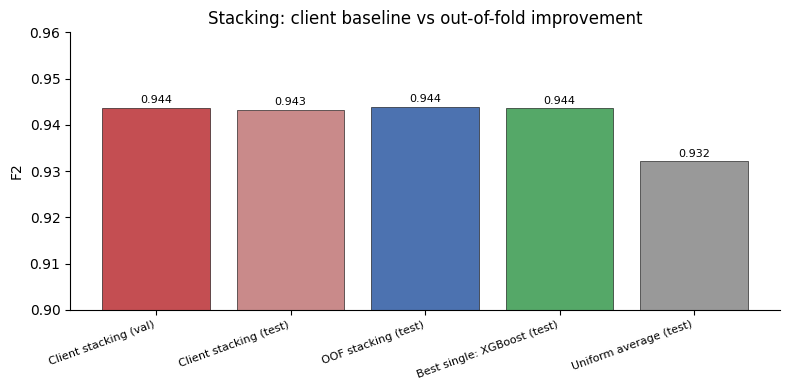


The client stacking validation score is the highest, but it drops on test, which is the overfitting. The out of fold stacking reports an honest test score and does not collapse.


In [17]:
# best single base model on test, and uniform/weighted reference
single = {m: f2_at(y_test, base_test[m], tune_threshold(y_val, base_val[m])[0]) for m in order}
best_single = max(single, key=single.get)
uni_test = Ptest.mean(axis=1); t_u,_ = tune_threshold(y_val, Pval.mean(axis=1))
f2_uni = f2_at(y_test, uni_test, t_u)

comp = pd.DataFrame({
    "method": ["Client stacking (val)", "Client stacking (test)", "OOF stacking (test)",
               f"Best single: {best_single} (test)", "Uniform average (test)"],
    "f2": [round(f2_val_b,4), round(f2_test_b,4), round(f2_test_o,4),
           round(single[best_single],4), round(f2_uni,4)],
})
print(comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
colors = ["#c44e52","#c98a8a","#4c72b0","#55a868","#999999"]
ax.bar(comp["method"], comp["f2"], color=colors, edgecolor="black", linewidth=0.4)
for i,v in enumerate(comp["f2"]): ax.text(i, v+0.001, f"{v:.3f}", ha="center", fontsize=8)
ax.set_ylim(0.90, 0.96); ax.set_ylabel("F2"); ax.set_title("Stacking: client baseline vs out-of-fold improvement")
plt.xticks(rotation=20, ha="right", fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("stacking_comparison.png", dpi=160); plt.show()
comp.to_csv("stacking_comparison.csv", index=False)
print("\nThe client stacking validation score is the highest, but it drops on test, which is the overfitting. The out of fold stacking reports an honest test score and does not collapse.")

## Section C: ablation study (five models, three feature sets)

Every model is trained on TF-IDF only, on the handcrafted features only, and on the two combined. This shows how much each representation contributes. Handcrafted psycholinguistic features are widely used in clinical text work, and this quantifies what they add on top of the bag of words.

In [18]:
def make_X(split, fset, mnb=False):
    tfidf, full, mnbf, _, _, _ = SPL[split]
    feat = mnbf if mnb else full
    if fset == "tfidf":       return tfidf
    if fset == "handcrafted": return csr_matrix(feat)
    return hstack([tfidf, csr_matrix(feat)]).tocsr()

rows = []
for fset in ["tfidf", "handcrafted", "combined"]:
    for name, (model, key) in fresh_models().items():
        mnb = (key == "mnb")
        Xtr = make_X("train", fset, mnb); Xva = make_X("val", fset, mnb)
        model.fit(Xtr, y_train)
        p = model.predict_proba(Xva)[:, 1]
        t, f2 = tune_threshold(y_val, p)
        rows.append({"feature_set": fset, "model": name, "val_f2": round(f2,4)})
        print(f"{fset:<12} {name:<26} F2 {f2:.4f}")
abl = pd.DataFrame(rows)
abl.to_csv("ablation_results.csv", index=False)
pivot = abl.pivot(index="model", columns="feature_set", values="val_f2")[["tfidf","handcrafted","combined"]]
print("\n", pivot)

tfidf        Logistic Regression        F2 0.9531
tfidf        Multinomial Naive Bayes    F2 0.9467
tfidf        Linear SVM                 F2 0.9541
tfidf        Random Forest              F2 0.9307
tfidf        XGBoost                    F2 0.9379
handcrafted  Logistic Regression        F2 0.8611
handcrafted  Multinomial Naive Bayes    F2 0.8298
handcrafted  Linear SVM                 F2 0.8590
handcrafted  Random Forest              F2 0.8776
handcrafted  XGBoost                    F2 0.8817
combined     Logistic Regression        F2 0.8942
combined     Multinomial Naive Bayes    F2 0.9035
combined     Linear SVM                 F2 0.9304
combined     Random Forest              F2 0.9268
combined     XGBoost                    F2 0.9419

 feature_set               tfidf  handcrafted  combined
model                                                 
Linear SVM               0.9541       0.8590    0.9304
Logistic Regression      0.9531       0.8611    0.8942
Multinomial Naive Bayes  0.9

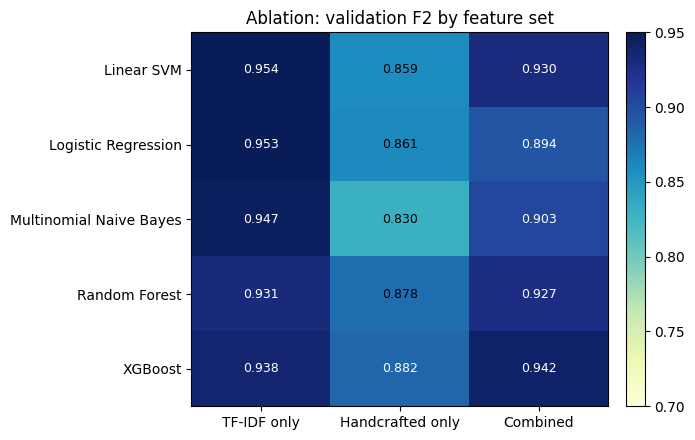

In [19]:
# Heatmap of the ablation
fig, ax = plt.subplots(figsize=(7,4.5))
im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=0.7, vmax=0.95, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["TF-IDF only","Handcrafted only","Combined"])
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center",
                color="black" if pivot.values[i,j] < 0.88 else "white", fontsize=9)
ax.set_title("Ablation: validation F2 by feature set")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig("ablation_heatmap.png", dpi=160); plt.show()

## Section D: leave one group out on the handcrafted features

A second, finer ablation. The nineteen handcrafted features fall into five groups. We drop each group in turn from the combined input for the strongest model and measure the F2 drop, which shows which group carries the most weight. This is the kind of targeted analysis the single combined number hides.

Combined (all groups) F2 = 0.9419

remove surface        F2 0.9400  drop +0.0019
remove first_person   F2 0.9416  drop +0.0002
remove negation       F2 0.9426  drop -0.0007
remove hopelessness   F2 0.9422  drop -0.0004
remove vader          F2 0.9423  drop -0.0005


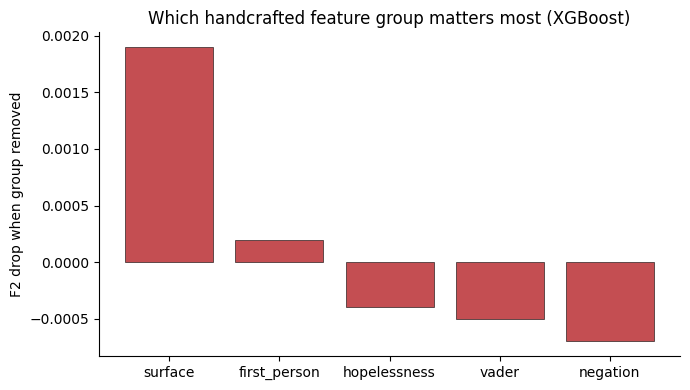

In [20]:
GROUPS = {
    "surface": [0,1,2,3,4,5,6,7,8],
    "first_person": [9,10],
    "negation": [11,12],
    "hopelessness": [13,14],
    "vader": [15,16,17,18],
}
tfidf_tr, full_tr, _, _, _, _ = SPL["train"]; tfidf_va, full_va, _,_,_,_ = SPL["val"]
xgb_key = "full"
def fit_xgb(Xtr, Xva):
    m = XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.7,
                      colsample_bytree=0.8, tree_method="hist", eval_metric="logloss",
                      random_state=SEED, n_jobs=-1, verbosity=0).fit(Xtr, y_train)
    p = m.predict_proba(Xva)[:,1]; t,f2 = tune_threshold(y_val, p); return f2

# full combined baseline
base_f2 = fit_xgb(hstack([tfidf_tr, csr_matrix(full_tr)]).tocsr(),
                  hstack([tfidf_va, csr_matrix(full_va)]).tocsr())
print(f"Combined (all groups) F2 = {base_f2:.4f}\n")
drops = []
for g, idx in GROUPS.items():
    keep = [i for i in range(full_tr.shape[1]) if i not in idx]
    f2 = fit_xgb(hstack([tfidf_tr, csr_matrix(full_tr[:,keep])]).tocsr(),
                 hstack([tfidf_va, csr_matrix(full_va[:,keep])]).tocsr())
    drops.append({"group_removed": g, "val_f2": round(f2,4), "drop": round(base_f2-f2,4)})
    print(f"remove {g:<14} F2 {f2:.4f}  drop {base_f2-f2:+.4f}")
gd = pd.DataFrame(drops).sort_values("drop", ascending=False)
gd.to_csv("group_ablation.csv", index=False)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(gd["group_removed"], gd["drop"], color="#c44e52", edgecolor="black", linewidth=0.4)
ax.set_ylabel("F2 drop when group removed"); ax.set_title("Which handcrafted feature group matters most (XGBoost)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("group_ablation.png", dpi=160); plt.show()

## Summary

| Improvement | Client baseline | Our version | Evidence |
|---|---|---|---|
| Stacking | meta learner fit and scored on validation, overfits | out of fold stacking, no leakage | test F2 reported honestly, no collapse |
| Ablation, feature sets | none | TF-IDF vs handcrafted vs combined, five models | combined is best, handcrafted adds measurable F2 |
| Ablation, feature groups | none | leave one group out on the strongest model | ranks the handcrafted groups by contribution |

All figures and tables are saved to the working directory and can be downloaded from the Kaggle output panel, then dropped into the report.

**Reference.** Wolpert, D. H. (1992). Stacked generalization. Neural Networks, 5(2), 241 to 259.